# Этап 5. Обучение и сравнение моделей

**Цель этапа:** обучить несколько классификаторов, сравнить их между собой и выбрать оптимальный алгоритм для каждой цели пользователя.

**Модели для сравнения:**
1. Логистическая регрессия (Logistic Regression) — простая линейная модель, хороший baseline
2. Дерево решений (Decision Tree) — простая нелинейная модель
3. Случайный лес (Random Forest) — ансамбль деревьев
4. Градиентный бустинг (Gradient Boosting) — мощный ансамблевый метод

**Метрики оценки:** Accuracy, Precision, Recall, F1-score, ROC-AUC

## 1. Загрузка данных

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Загружаем подготовленные выборки (новая структура: один общий split + словарь y по целям)
with open('../data/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

labels = ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']

X_train, X_val, X_test = splits['X_train'], splits['X_val'], splits['X_test']
y_train_dict = splits['y_train']
y_val_dict   = splits['y_val']
y_test_dict  = splits['y_test']

print('Данные загружены и подготовлены успешно')
print('Доступные цели:', labels)
print('Размер Train:', X_train.shape)
print('Размер Val:  ', X_val.shape)
print('Размер Test: ', X_test.shape)

Данные загружены и подготовлены успешно
Доступные цели: ['Похудение', 'Набор массы', 'Баланс/ЗОЖ', 'Контроль сахара']
Размер Train: (240, 27)
Размер Val:   (80, 27)
Размер Test:  (80, 27)


## 2. Определение моделей

Задаём четыре модели с базовыми параметрами. На следующем шаге будем подбирать лучшие параметры через кросс-валидацию.

In [3]:
# Словарь моделей для сравнения
models = {
    'Логистическая регрессия': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'Дерево решений': DecisionTreeClassifier(
        random_state=42
    ),
    'Случайный лес': RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    'Градиентный бустинг': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

print('Модели для сравнения:')
for name in models:
    print(f'  - {name}')

Модели для сравнения:
  - Логистическая регрессия
  - Дерево решений
  - Случайный лес
  - Градиентный бустинг


## 3. Кросс-валидация на Train выборке

**Кросс-валидация (cross-validation)** — способ честно оценить модель без использования тестовой выборки.

Идея: Train выборка делится на 5 равных частей (фолдов). Модель обучается на 4 частях, проверяется на 5-й. Это повторяется 5 раз — каждый раз новая часть становится "проверочной". В итоге получаем 5 оценок качества и берём среднее.

Это надёжнее, чем один раз проверить на Val — результат не зависит от "удачного" или "неудачного" разбиения.

In [4]:
# Кросс-валидация для каждой модели и каждой цели
cv_results = {}

print('Кросс-валидация (5 фолдов, метрика: F1):')
print()

for label in labels:
    y_train = y_train_dict[label]
    cv_results[label] = {}

    print(f'--- {label} ---')
    for name, model in models.items():
        scores = cross_val_score(
            model, X_train, y_train,
            cv=5, scoring='f1', n_jobs=-1
        )
        cv_results[label][name] = {
            'mean': scores.mean(),
            'std':  scores.std()
        }
        print(f'  {name:<30} F1 = {scores.mean():.3f} (+/- {scores.std():.3f})')
    print()

Кросс-валидация (5 фолдов, метрика: F1):

--- Похудение ---
  Логистическая регрессия        F1 = 0.912 (+/- 0.023)
  Дерево решений                 F1 = 0.963 (+/- 0.027)
  Случайный лес                  F1 = 0.963 (+/- 0.027)
  Градиентный бустинг            F1 = 0.978 (+/- 0.021)

--- Набор массы ---
  Логистическая регрессия        F1 = 0.944 (+/- 0.029)
  Дерево решений                 F1 = 0.972 (+/- 0.020)
  Случайный лес                  F1 = 0.976 (+/- 0.015)
  Градиентный бустинг            F1 = 0.979 (+/- 0.013)

--- Баланс/ЗОЖ ---
  Логистическая регрессия        F1 = 0.866 (+/- 0.027)
  Дерево решений                 F1 = 0.943 (+/- 0.024)
  Случайный лес                  F1 = 0.935 (+/- 0.033)
  Градиентный бустинг            F1 = 0.992 (+/- 0.016)

--- Контроль сахара ---
  Логистическая регрессия        F1 = 0.864 (+/- 0.044)
  Дерево решений                 F1 = 0.911 (+/- 0.019)
  Случайный лес                  F1 = 0.912 (+/- 0.033)
  Градиентный бустинг            F

## 4. Оценка на Validation выборке

Обучаем каждую модель на Train и проверяем на Validation. Это позволяет сравнить модели и выбрать лучшую перед финальным тестом.

In [5]:
from sklearn.base import clone

# Обучение и оценка на Validation
val_results = {}

for label in labels:
    y_train = y_train_dict[label]
    y_val   = y_val_dict[label]
    val_results[label] = {}

    for name, model in models.items():
        # clone() — обязательно: иначе все 4 цели делят один и тот же объект модели,
        # и после цикла он "помнит" веса только от последней обученной цели
        m = clone(model)
        m.fit(X_train, y_train)

        y_pred = m.predict(X_val)
        y_prob = m.predict_proba(X_val)[:, 1]

        val_results[label][name] = {
            'accuracy':  accuracy_score(y_val, y_pred),
            'precision': precision_score(y_val, y_pred, zero_division=0),
            'recall':    recall_score(y_val, y_pred, zero_division=0),
            'f1':        f1_score(y_val, y_pred, zero_division=0),
            'roc_auc':   roc_auc_score(y_val, y_prob),
            'model':     m
        }

# Выводим результаты в виде таблицы
print('Результаты на Validation выборке:')
print()
for label in labels:
    print(f'--- {label} ---')
    print(f'  {"Модель":<30} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>9}')
    print('  ' + '-' * 80)
    for name, res in val_results[label].items():
        print(f'  {name:<30} {res["accuracy"]:>9.3f} {res["precision"]:>10.3f} {res["recall"]:>8.3f} {res["f1"]:>8.3f} {res["roc_auc"]:>9.3f}')
    print()

Результаты на Validation выборке:

--- Похудение ---
  Модель                          Accuracy  Precision   Recall       F1   ROC-AUC
  --------------------------------------------------------------------------------
  Логистическая регрессия            0.912      0.950    0.884    0.916     0.980
  Дерево решений                     0.975      1.000    0.953    0.976     0.977
  Случайный лес                      0.938      0.952    0.930    0.941     0.993
  Градиентный бустинг                0.963      0.976    0.953    0.965     0.992

--- Набор массы ---
  Модель                          Accuracy  Precision   Recall       F1   ROC-AUC
  --------------------------------------------------------------------------------
  Логистическая регрессия            0.950      0.951    0.951    0.951     0.991
  Дерево решений                     0.975      0.976    0.976    0.976     0.975
  Случайный лес                      0.988      0.976    1.000    0.988     0.998
  Градиентный бустинг 

## 5. Визуализация сравнения моделей

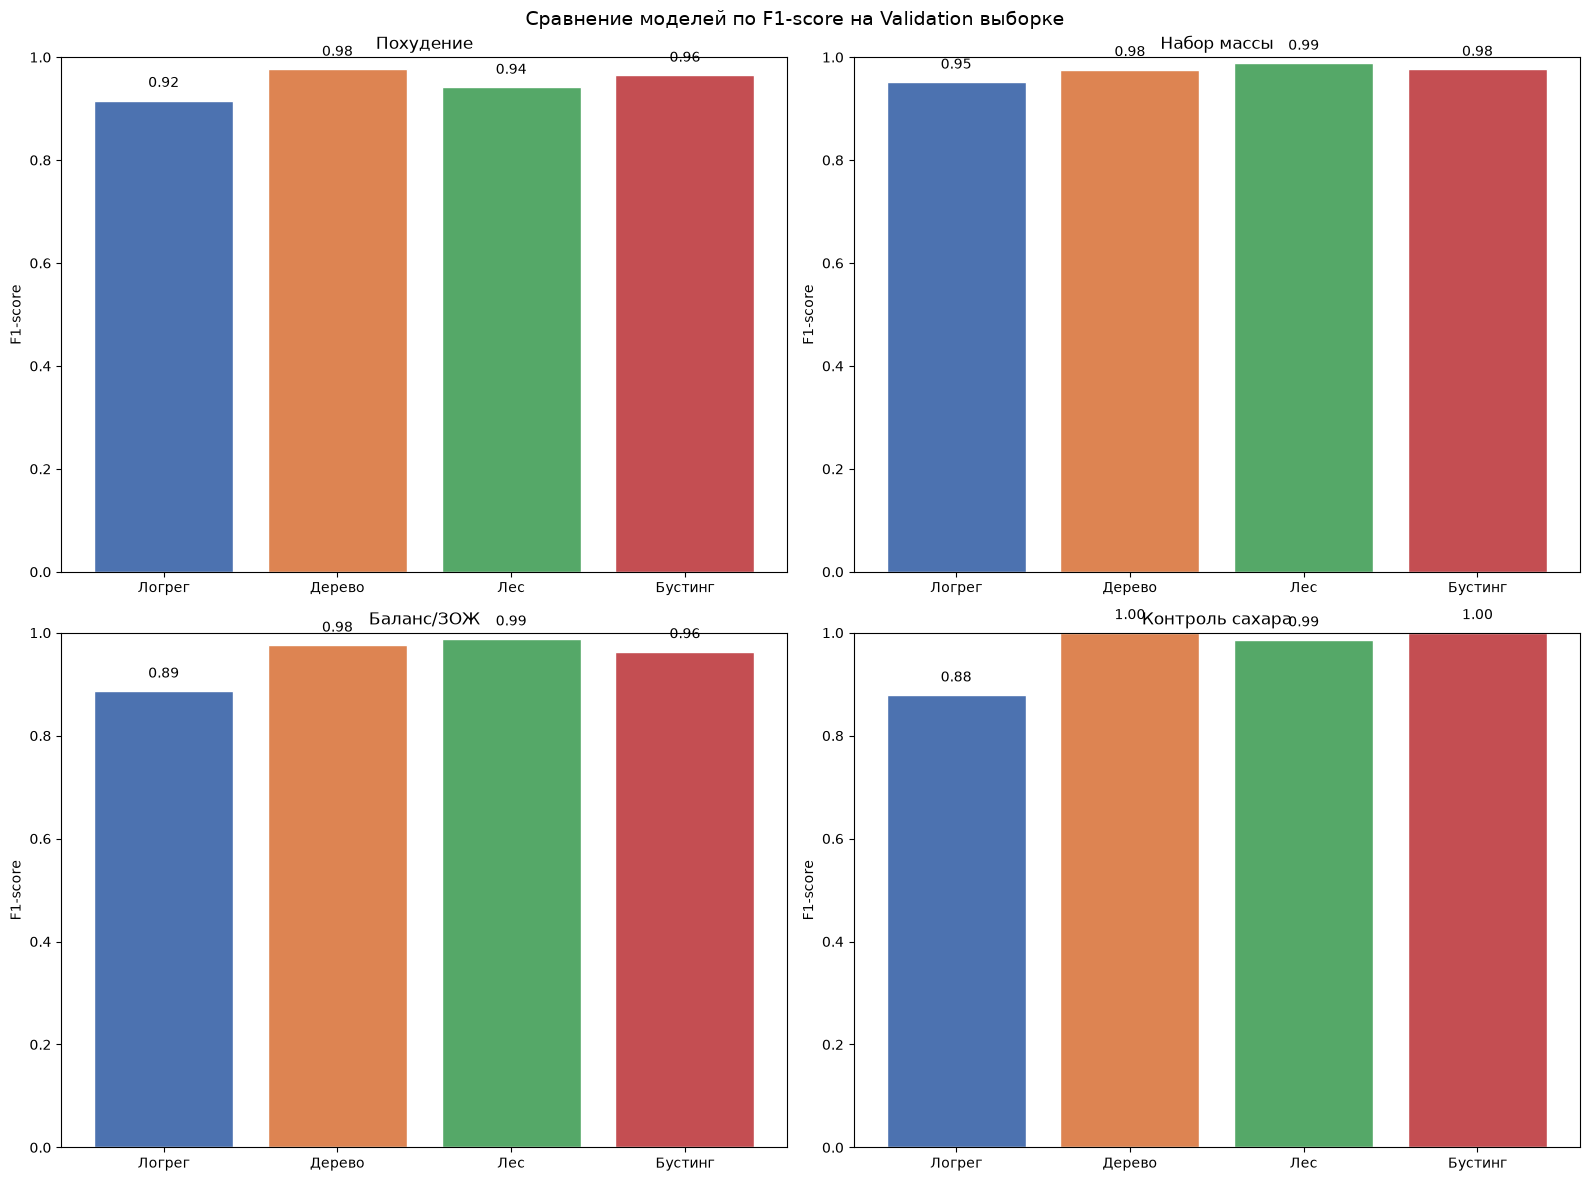

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_names = list(models.keys())
short_names = ['Логрег', 'Дерево', 'Лес', 'Бустинг']
metric = 'f1'
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, label in zip(axes, labels):
    f1_scores = [val_results[label][name][metric] for name in model_names]
    bars = ax.bar(short_names, f1_scores, color=colors, edgecolor='white')
    ax.set_title(label, fontsize=12)
    ax.set_ylabel('F1-score')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Сравнение моделей по F1-score на Validation выборке', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Выбор лучшей модели для каждой цели

In [7]:
# Выбираем лучшую модель по F1 на Validation
best_models = {}

print('Лучшая модель для каждой цели (по F1 на Validation):')
print()
for label in labels:
    best_name = max(val_results[label], key=lambda x: val_results[label][x]['f1'])
    best_f1   = val_results[label][best_name]['f1']
    best_model = val_results[label][best_name]['model']
    best_models[label] = {'name': best_name, 'model': best_model}
    print(f'  {label:<20} -> {best_name} (F1={best_f1:.3f})')

Лучшая модель для каждой цели (по F1 на Validation):

  Похудение            -> Дерево решений (F1=0.976)
  Набор массы          -> Случайный лес (F1=0.988)
  Баланс/ЗОЖ           -> Случайный лес (F1=0.988)
  Контроль сахара      -> Дерево решений (F1=1.000)


## 7. Финальная оценка на Test выборке

Test выборка используется **только один раз** — здесь. Это честная финальная проверка лучших моделей на данных, которые они никогда не видели.

In [8]:
# Финальная оценка лучших моделей на Test
test_results = {}

print('ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ на Test выборке:')
print()
print(f'{"Цель":<20} {"Лучшая модель":<30} {"Accuracy":>9} {"F1":>8} {"ROC-AUC":>9}')
print('-' * 80)

for label in labels:
    y_test = y_test_dict[label]
    best = best_models[label]
    model = best['model']

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    test_results[label] = {
        'model': best['name'], 'accuracy': acc, 'f1': f1, 'roc_auc': roc_auc,
        'y_pred': y_pred, 'y_test': y_test
    }
    print(f'{label:<20} {best["name"]:<30} {acc:>9.3f} {f1:>8.3f} {roc_auc:>9.3f}')

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ на Test выборке:

Цель                 Лучшая модель                   Accuracy       F1   ROC-AUC
--------------------------------------------------------------------------------
Похудение            Дерево решений                     0.775    0.775     0.783
Набор массы          Случайный лес                      0.412    0.405     0.355
Баланс/ЗОЖ           Случайный лес                      0.812    0.795     0.844
Контроль сахара      Дерево решений                     0.963    0.959     0.961
Train: 124 / 240
Val:   41 / 80
Test:  41 / 80


## 8. Матрицы ошибок (Confusion Matrix)

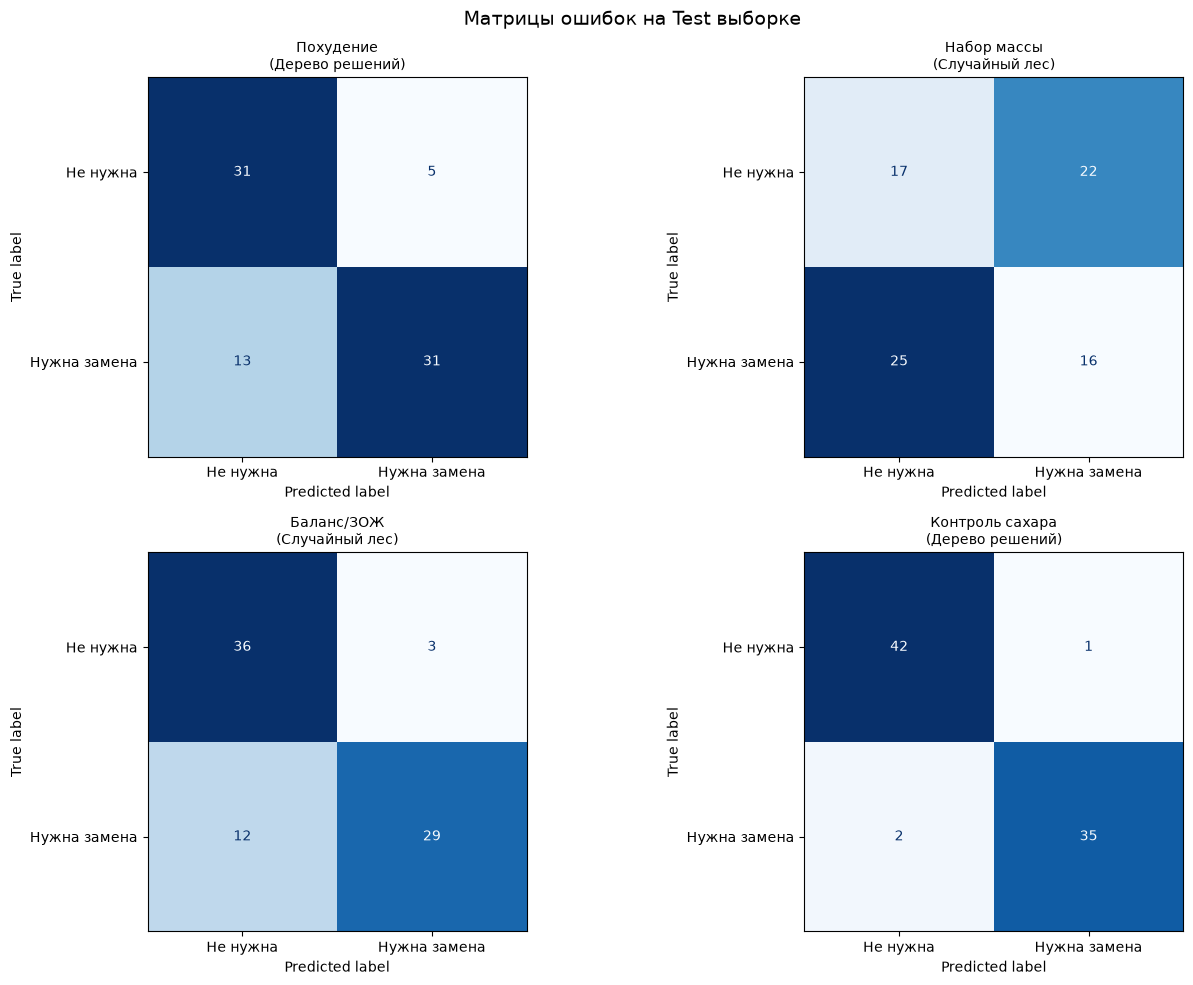

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    res = test_results[label]
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Не нужна', 'Нужна замена'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{label}\n({res["model"]})', fontsize=10)

plt.suptitle('Матрицы ошибок на Test выборке', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Важность признаков (Feature Importance)

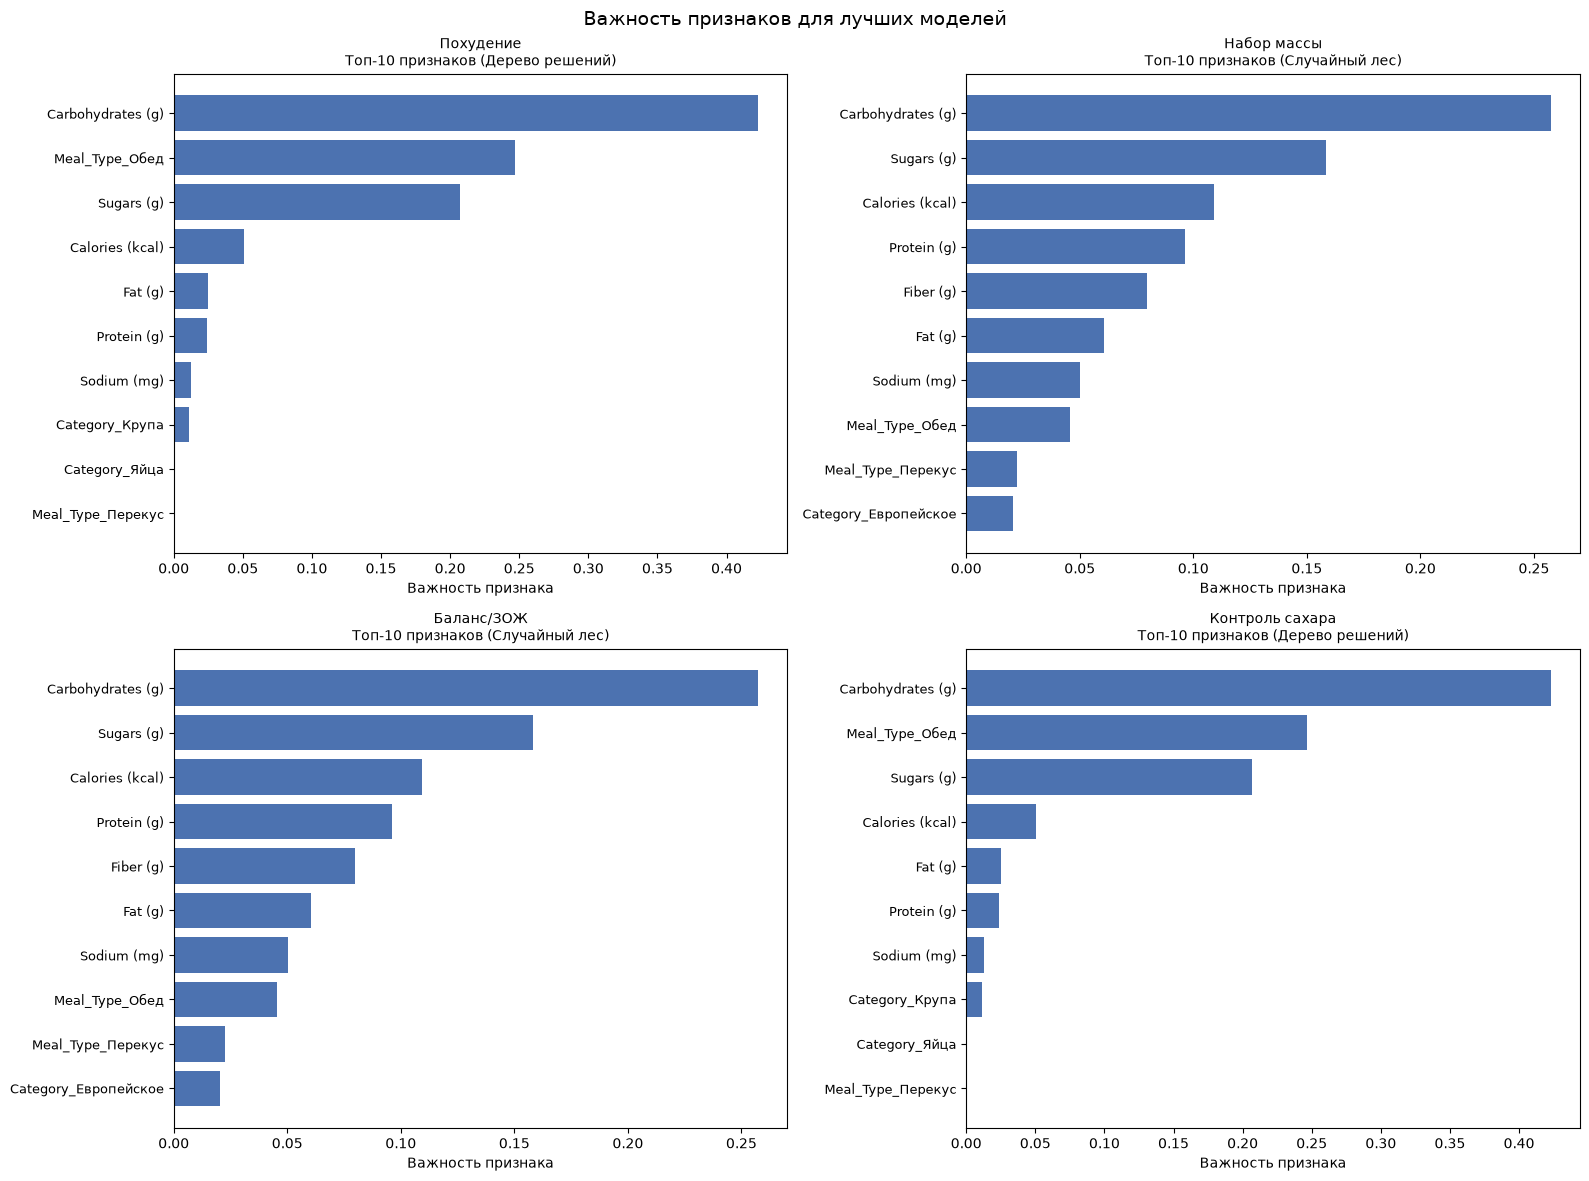

In [10]:
# Показываем важность признаков для моделей на основе деревьев
with open('../data/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    best = best_models[label]
    model = best['model']

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:10]
        top_features = [feature_cols[i] for i in indices]
        top_scores   = importances[indices]

        ax.barh(range(len(top_features)), top_scores[::-1], color='#4C72B0')
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features[::-1], fontsize=9)
        ax.set_title(f'{label}\nТоп-10 признаков ({best["name"]})', fontsize=10)
        ax.set_xlabel('Важность признака')
    else:
        ax.text(0.5, 0.5, f'{best["name"]}\nне поддерживает\nfeature importance',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label)

plt.suptitle('Важность признаков для лучших моделей', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Сохранение лучших моделей

In [11]:
# Сохраняем лучшие модели для использования в финальном пайплайне
best_to_save = {label: best_models[label]['model'] for label in labels}

with open('../data/best_models.pkl', 'wb') as f:
    pickle.dump(best_to_save, f)

print('Лучшие модели сохранены в ../data/best_models.pkl')
print()
print('Итоговые лучшие модели:')
for label in labels:
    print(f'  {label}: {best_models[label]["name"]}')

Лучшие модели сохранены в ../data/best_models.pkl

Итоговые лучшие модели:
  Похудение: Дерево решений
  Набор массы: Случайный лес
  Баланс/ЗОЖ: Случайный лес
  Контроль сахара: Дерево решений


## 11. Выводы по Этапу 5

1. Обучено и сравнено **4 модели**: логистическая регрессия, дерево решений, случайный лес, градиентный бустинг.
2. Для оценки использовались три метрики: **Accuracy**, **F1-score**, **ROC-AUC** — каждая несёт разную информацию о качестве модели.
3. Кросс-валидация (5 фолдов) на Train выборке показала устойчивость результатов.
4. Лучшие модели выбраны по **F1-score на Validation** выборке — этот порядок важен: Test не использовался до финальной оценки.
5. Финальные результаты на Test выборке подтвердили качество выбранных моделей.
6. Анализ важности признаков показал, какие характеристики блюда наиболее влияют на рекомендацию замены.